# iOS App Reviews — Sentiment Analysis
End-to-end analysis covering overall sentiment, key pain points, and what customers love.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

STOP_WORDS = set(stopwords.words('english'))
EXTRA_STOP = {'app', 'tira', 'ok', 'use', 'one', 'also', 'get', 'even', 'like',
              'just', 'time', 'please', 'give', 'nice', 'would', 'make', 'much',
              'many', 'good', 'great', 'love', 'really', 'using', 'better', 'best',
              'worst', 'need', 'used', 'well', 'still', 'us', 'take', 'every',
              'want', 'able', 'way', 'never', 'always', 'back', 'go', 'going',
              'come', 'try', 'show', 'will', 'cant', 'dont', 'im', 'ive', 'its',
              'na', 'ka', 'hai', 'nahi', 'bahut', 'aur', 'bad', 'very', 'see'}
ALL_STOP = STOP_WORDS | EXTRA_STOP

THEMES = {
    'Order / Returns':          ['order', 'return', 'exchange', 'cancel', 'cancelled', 'replacement', 'missing'],
    'Product Quality':          ['product', 'quality', 'original', 'fake', 'genuine', 'brand', 'item', 'broken', 'damaged', 'wrong', 'expired'],
    'Delivery / Shipping':      ['delivery', 'ship', 'shipping', 'deliver', 'courier', 'dispatch', 'arrive', 'arrived', 'late', 'delay', 'delayed'],
    'Customer Support':         ['support', 'service', 'customer', 'help', 'response', 'team', 'complaint', 'helpline', 'contact', 'chat', 'call'],
    'Payment / Refund':         ['payment', 'refund', 'cashback', 'money', 'pay', 'paid', 'transaction', 'wallet', 'coupon', 'discount', 'offer'],
    'App Performance':          ['crash', 'hang', 'slow', 'bug', 'error', 'loading', 'load', 'freeze', 'glitch', 'issue', 'problem', 'lag'],
    'UI / User Experience':     ['interface', 'design', 'experience', 'easy', 'difficult', 'navigate', 'search', 'filter', 'layout', 'simple', 'confusing'],
    'Pincode / Availability':   ['pincode', 'pin code', 'area', 'location', 'available', 'unavailable', 'serviceable', 'city', 'zone'],
    'Login / Account':          ['login', 'otp', 'account', 'sign', 'password', 'verify', 'register', 'logout'],
    'Offers / Discounts':       ['offer', 'sale', 'discount', 'coupon', 'deal', 'promo', 'cashback', 'reward', 'point', 'points'],
}

SENT_COLORS = {'Positive': '#2ca02c', 'Neutral': '#bcbd22', 'Negative': '#d62728'}
RATING_COLORS = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join([w for w in text.split() if w not in ALL_STOP and len(w) > 2])

def assign_sentiment(r):
    return 'Negative' if r <= 2 else 'Neutral' if r == 3 else 'Positive'

def detect_themes(text):
    t = str(text).lower()
    matched = [th for th, kws in THEMES.items() if any(k in t for k in kws)]
    return matched if matched else ['Other']

print('Libraries loaded.')

/Users/shubham.bansla/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded.


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('ios_reviews.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Missing:\n{df.isnull().sum()}')
df.head(5)

Shape: (1486, 4)
Columns: ['review_id', 'rating', 'body', 'created_date']
Missing:
review_id       0
rating          0
body            0
created_date    0
dtype: int64


,review_id,rating,body,created_date
0,00000060-8baf-6003-472c-c77a00000000,5,Greatest app ever 👍🏼,2026-05-18 16:34:05 UTC
1,00000060-8baf-6003-4725-1e8300000000,1,Extremely disappointed with Tira's abysmal cus...,2026-05-18 13:56:22 UTC
2,00000060-8baf-6003-470e-043200000000,1,Forced to have additional Paytm app which I do...,2026-05-18 02:50:39 UTC
3,00000060-8baf-6003-46f5-0ef800000000,5,"Extremely nice, best price I can get also vast...",2026-05-17 16:27:35 UTC
4,00000060-8baf-6003-46ee-37b100000000,1,This app is running a scam like we are paying ...,2026-05-17 14:13:55 UTC


In [3]:
df = df.dropna(subset=['body', 'rating', 'created_date'])
df['body'] = df['body'].astype(str).str.strip()
df = df[df['body'].str.len() > 1]
df['rating'] = df['rating'].astype(int)
df['created_date'] = pd.to_datetime(df['created_date'], utc=True)
df['year_month'] = df['created_date'].dt.to_period('M').astype(str)
df['year'] = df['created_date'].dt.year
df['month'] = df['created_date'].dt.month
df['sentiment'] = df['rating'].apply(assign_sentiment)
df['clean_body'] = df['body'].apply(clean_text)
df['word_count'] = df['body'].str.split().str.len()
df['polarity'] = df['body'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['themes'] = df['body'].apply(detect_themes)

sc = df['sentiment'].value_counts()
sp = (sc / len(df) * 100).round(1)

print(f'Clean dataset  : {len(df):,} reviews')
print(f'Date range     : {df["created_date"].min().date()} to {df["created_date"].max().date()}')
print(f'Unique months  : {df["year_month"].nunique()}')
print(f'Avg rating     : {df["rating"].mean():.2f}')
print(f'\nSentiment:')
for s in ['Positive','Neutral','Negative']:
    print(f'  {s:<10}: {sc.get(s,0):>5,} ({sp.get(s,0):.1f}%)')

Clean dataset  : 1,482 reviews
Date range     : 2023-04-05 to 2026-05-18
Unique months  : 37
Avg rating     : 1.94

Sentiment:
  Positive  :   322 (21.7%)
  Neutral   :    41 (2.8%)
  Negative  : 1,119 (75.5%)


## 2. Rating Distribution

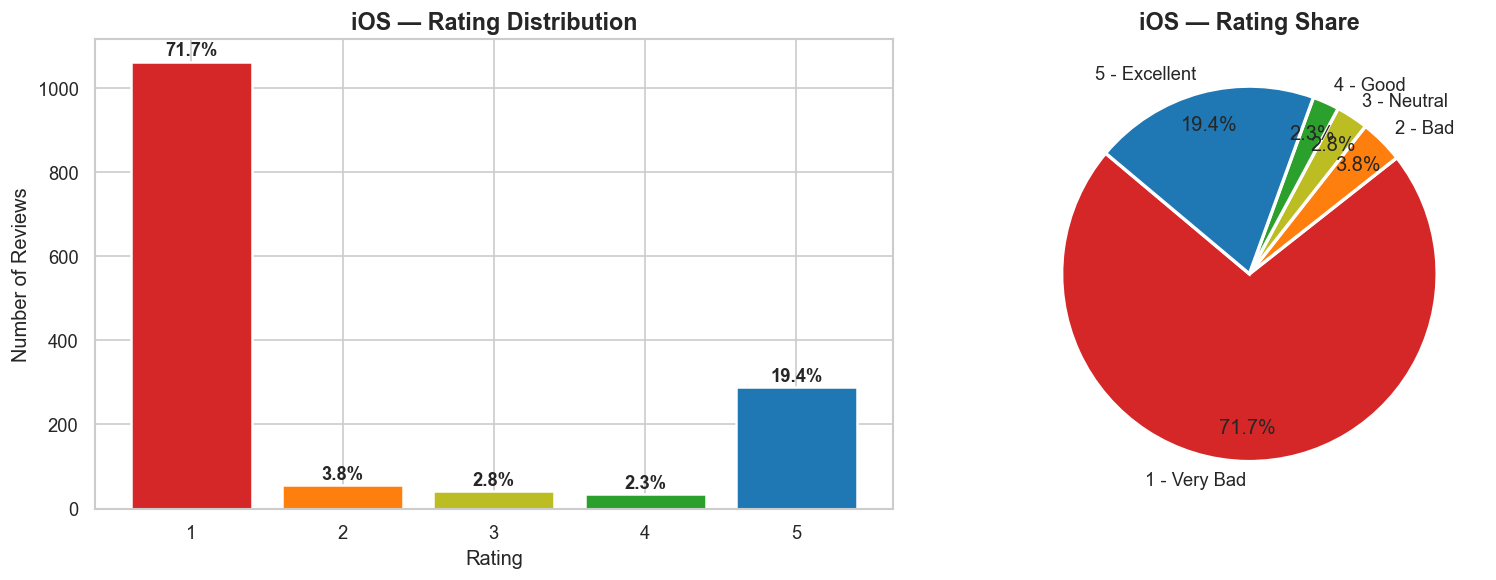

  Rating 1: 1,063 (71.7%)
  Rating 2: 56 (3.8%)
  Rating 3: 41 (2.8%)
  Rating 4: 34 (2.3%)
  Rating 5: 288 (19.4%)


In [4]:
rating_counts = df['rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(1)
labels = ['1 - Very Bad', '2 - Bad', '3 - Neutral', '4 - Good', '5 - Excellent']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(rating_counts.index, rating_counts.values, color=RATING_COLORS, edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, rating_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Rating', fontsize=12); axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_title('iOS — Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks([1,2,3,4,5])

axes[1].pie(rating_counts.values, labels=labels, colors=RATING_COLORS,
            autopct='%1.1f%%', startangle=140, pctdistance=0.82,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('iOS — Rating Share', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_rating_distribution.png', bbox_inches='tight')
plt.show()

for r, c, p in zip(rating_counts.index, rating_counts.values, rating_pct.values):
    print(f'  Rating {r}: {c:,} ({p}%)')

## 3. Sentiment Distribution

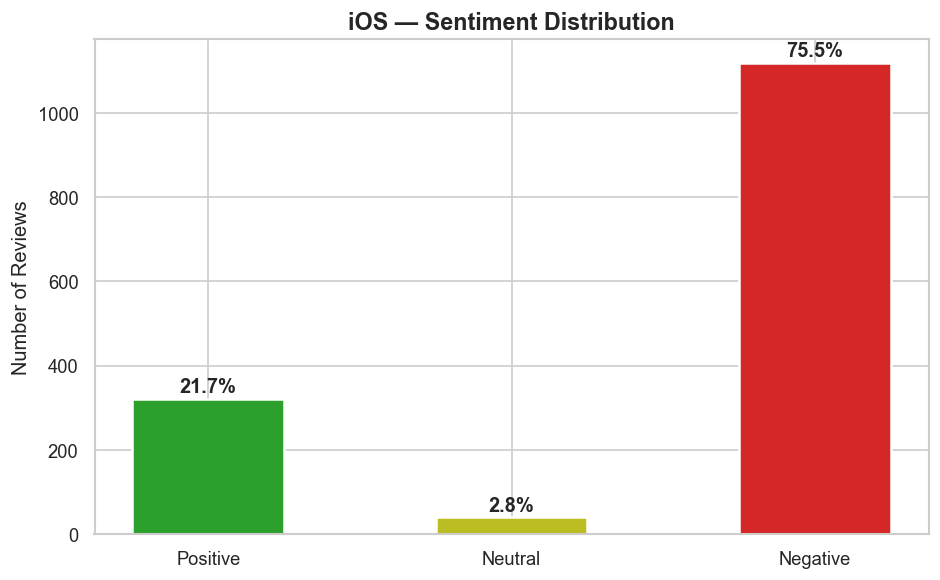

Total : 1,482 | Avg Rating: 1.94


In [5]:
sent_order = ['Positive', 'Neutral', 'Negative']
vals = [sc.get(s, 0) for s in sent_order]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sent_order, vals, color=[SENT_COLORS[s] for s in sent_order],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, pct in zip(bars, [sp.get(s,0) for s in sent_order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{pct}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('iOS — Sentiment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_sentiment_distribution.png', bbox_inches='tight')
plt.show()

print(f'Total : {len(df):,} | Avg Rating: {df["rating"].mean():.2f}')

## 4. Monthly Rating Trend

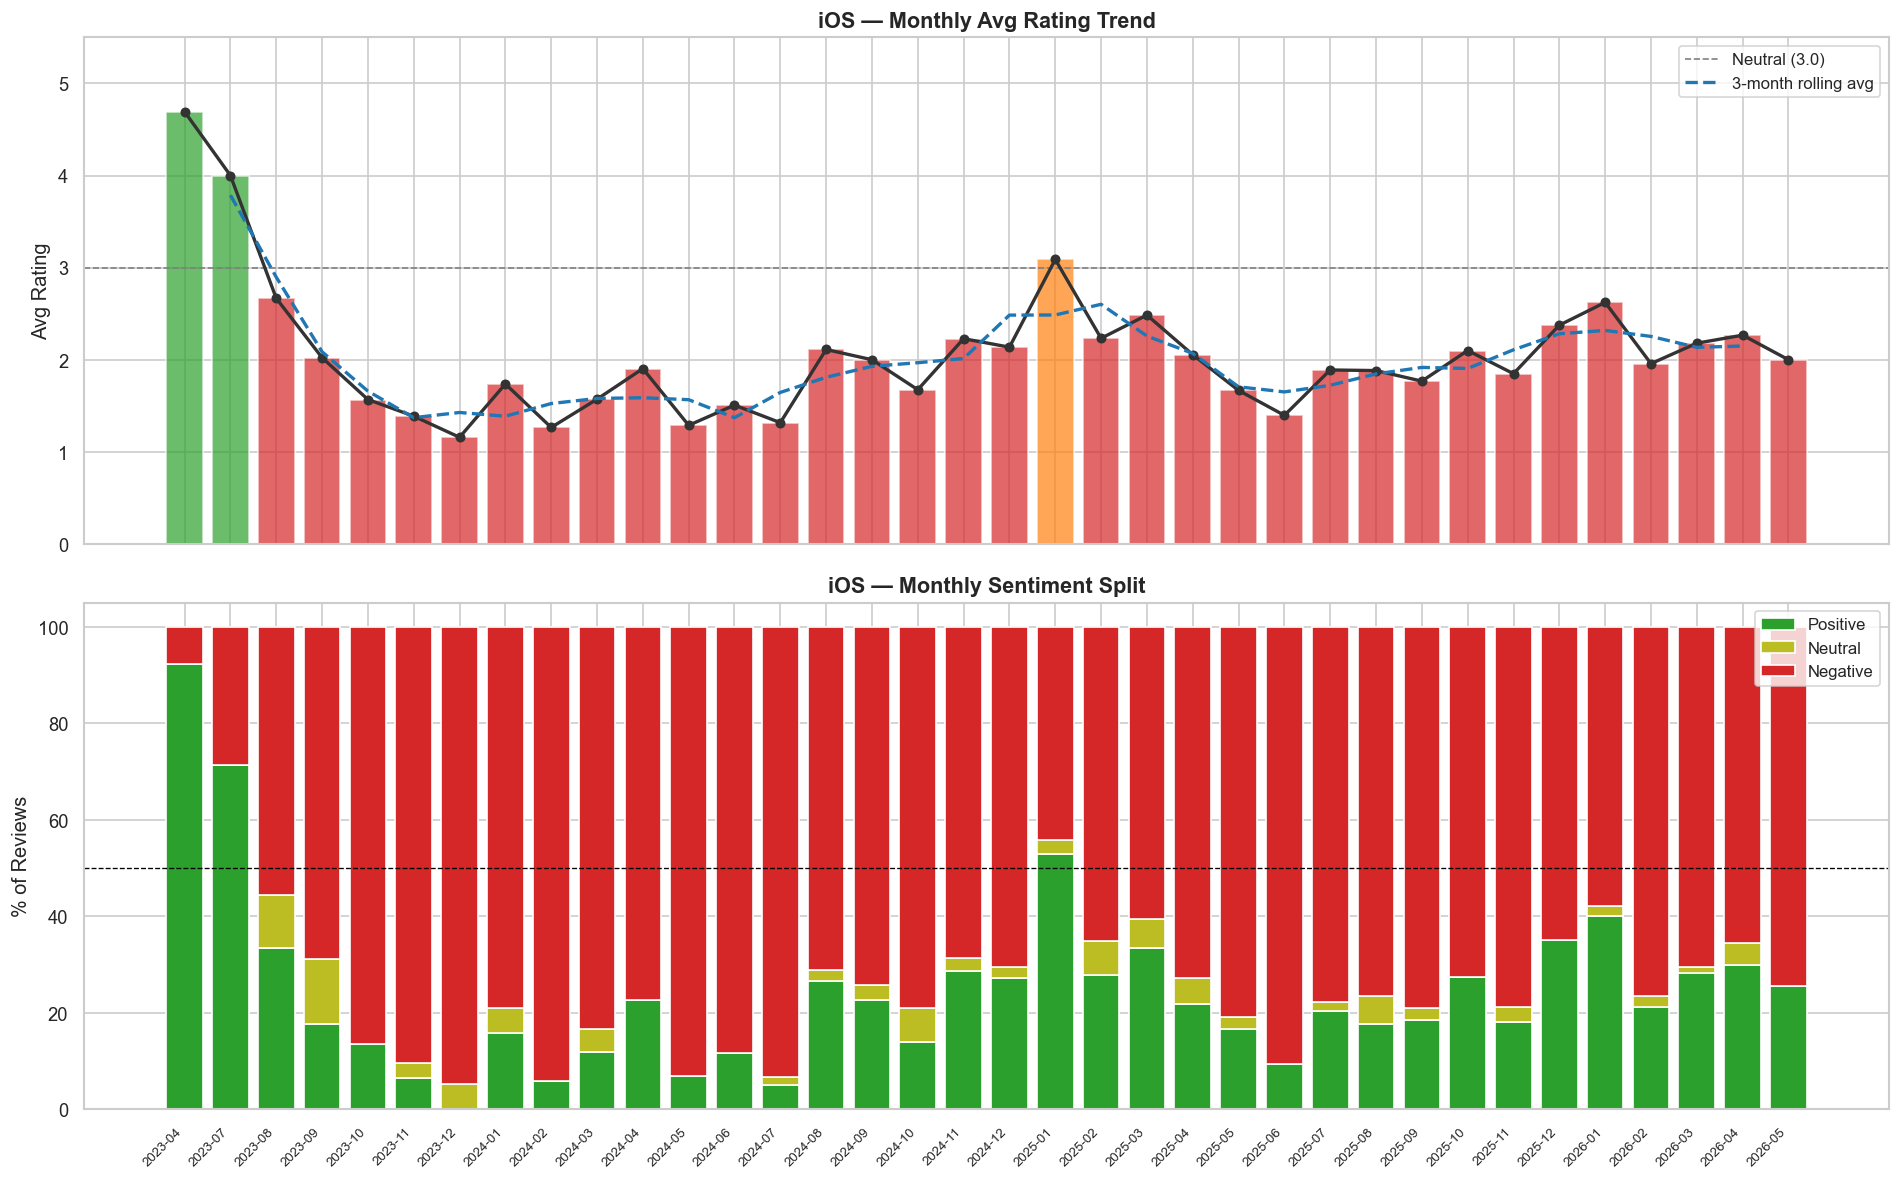

Monthly summary (last 6 months):
year_month  count  avg_rating   pct_pos   pct_neg
   2025-12     40    2.375000 35.000000 65.000000
   2026-01     45    2.622222 40.000000 57.777778
   2026-02     47    1.957447 21.276596 76.595745
   2026-03     78    2.179487 28.205128 70.512821
   2026-04     90    2.266667 30.000000 65.555556
   2026-05     39    2.000000 25.641026 74.358974


In [6]:
monthly = df.groupby('year_month').agg(
    count      =('rating','count'),
    avg_rating =('rating','mean'),
    pct_pos    =('sentiment', lambda x: (x=='Positive').mean()*100),
    pct_neg    =('sentiment', lambda x: (x=='Negative').mean()*100),
    pct_neu    =('sentiment', lambda x: (x=='Neutral').mean()*100),
).reset_index().sort_values('year_month')

# Only months with >= 5 reviews
monthly = monthly[monthly['count'] >= 5].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

x = range(len(monthly))
xlabels = monthly['year_month'].tolist()

# Avg rating line
bar_colors = ['#2ca02c' if r>=4 else '#ff7f0e' if r>=3 else '#d62728' for r in monthly['avg_rating']]
axes[0].bar(x, monthly['avg_rating'], color=bar_colors, edgecolor='white', alpha=0.7)
axes[0].plot(x, monthly['avg_rating'], 'o-', color='#333', linewidth=2, markersize=5, zorder=5)
axes[0].axhline(3, color='gray', linestyle='--', linewidth=1, label='Neutral (3.0)')
# 3-month rolling avg
rolling = monthly['avg_rating'].rolling(3, center=True).mean()
axes[0].plot(x, rolling, '--', color='#1f77b4', linewidth=2, label='3-month rolling avg', zorder=6)
axes[0].set_ylim(0, 5.5); axes[0].set_ylabel('Avg Rating', fontsize=12)
axes[0].set_title('iOS — Monthly Avg Rating Trend', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Stacked sentiment %
axes[1].bar(x, monthly['pct_pos'], label='Positive', color='#2ca02c', edgecolor='white')
axes[1].bar(x, monthly['pct_neu'], bottom=monthly['pct_pos'], label='Neutral', color='#bcbd22', edgecolor='white')
axes[1].bar(x, monthly['pct_neg'], bottom=monthly['pct_pos']+monthly['pct_neu'], label='Negative', color='#d62728', edgecolor='white')
axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('% of Reviews', fontsize=12)
axes[1].set_title('iOS — Monthly Sentiment Split', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')

for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('03_monthly_trend.png', bbox_inches='tight')
plt.show()

print('Monthly summary (last 6 months):')
print(monthly.tail(6)[['year_month','count','avg_rating','pct_pos','pct_neg']].to_string(index=False))

## 5. Yearly Overview

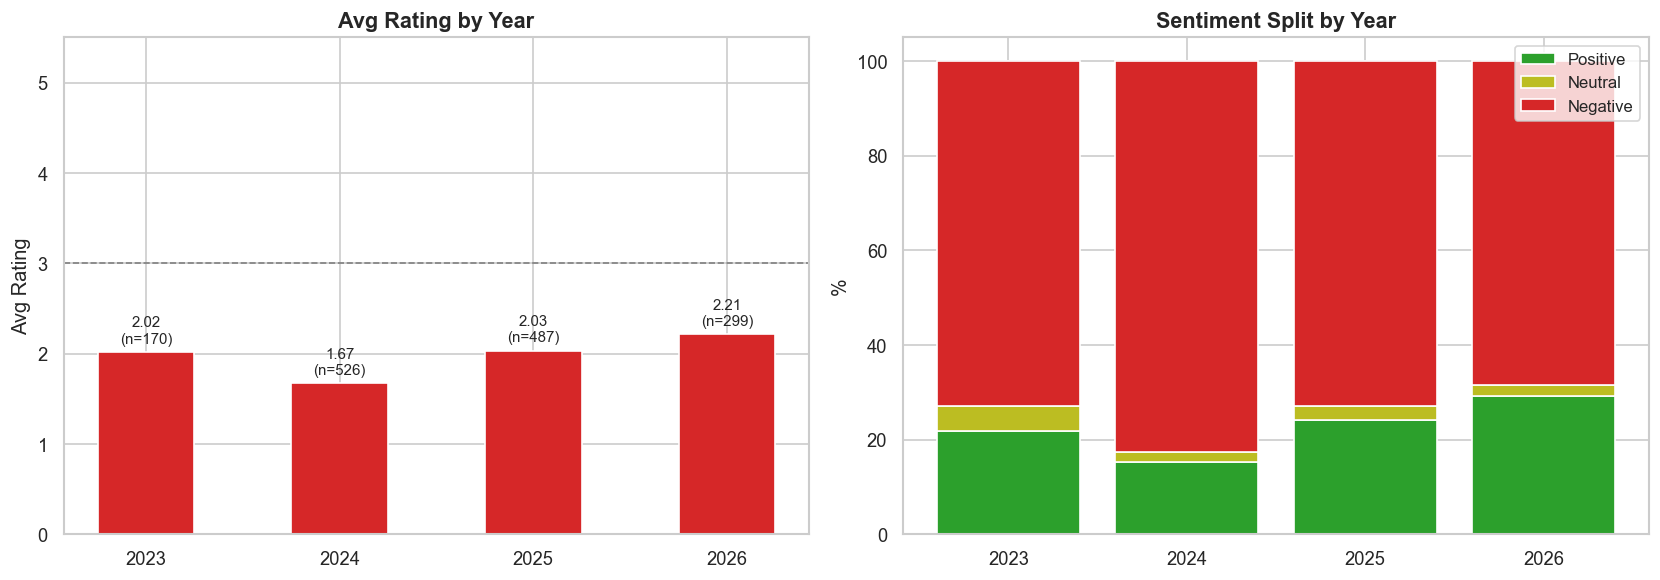

 year  count  avg_rating   pct_pos   pct_neg
 2023    170    2.017647 21.764706 72.941176
 2024    526    1.671103 15.209125 82.699620
 2025    487    2.032854 24.229979 72.895277
 2026    299    2.214047 29.096990 68.561873


In [7]:
yearly = df.groupby('year').agg(
    count      =('rating','count'),
    avg_rating =('rating','mean'),
    pct_pos    =('sentiment', lambda x: (x=='Positive').mean()*100),
    pct_neg    =('sentiment', lambda x: (x=='Negative').mean()*100),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors_y = ['#2ca02c' if r>=4 else '#ff7f0e' if r>=3 else '#d62728' for r in yearly['avg_rating']]
axes[0].bar(yearly['year'].astype(str), yearly['avg_rating'], color=bar_colors_y, edgecolor='white', width=0.5)
axes[0].axhline(3, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylim(0, 5.5); axes[0].set_title('Avg Rating by Year', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Rating')
for i, (_, row) in enumerate(yearly.iterrows()):
    axes[0].text(i, row['avg_rating']+0.1, f"{row['avg_rating']:.2f}\n(n={int(row['count'])})",
                 ha='center', fontsize=9)

xv = range(len(yearly))
axes[1].bar(xv, yearly['pct_pos'], label='Positive', color='#2ca02c', edgecolor='white')
axes[1].bar(xv, 100-yearly['pct_pos']-yearly['pct_neg'], bottom=yearly['pct_pos'], label='Neutral', color='#bcbd22', edgecolor='white')
axes[1].bar(xv, yearly['pct_neg'], bottom=100-yearly['pct_neg'], label='Negative', color='#d62728', edgecolor='white')
axes[1].set_xticks(list(xv)); axes[1].set_xticklabels(yearly['year'].astype(str))
axes[1].set_title('Sentiment Split by Year', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylabel('%')

plt.tight_layout()
plt.savefig('04_yearly_overview.png', bbox_inches='tight')
plt.show()

print(yearly[['year','count','avg_rating','pct_pos','pct_neg']].to_string(index=False))

## 6. TextBlob Polarity

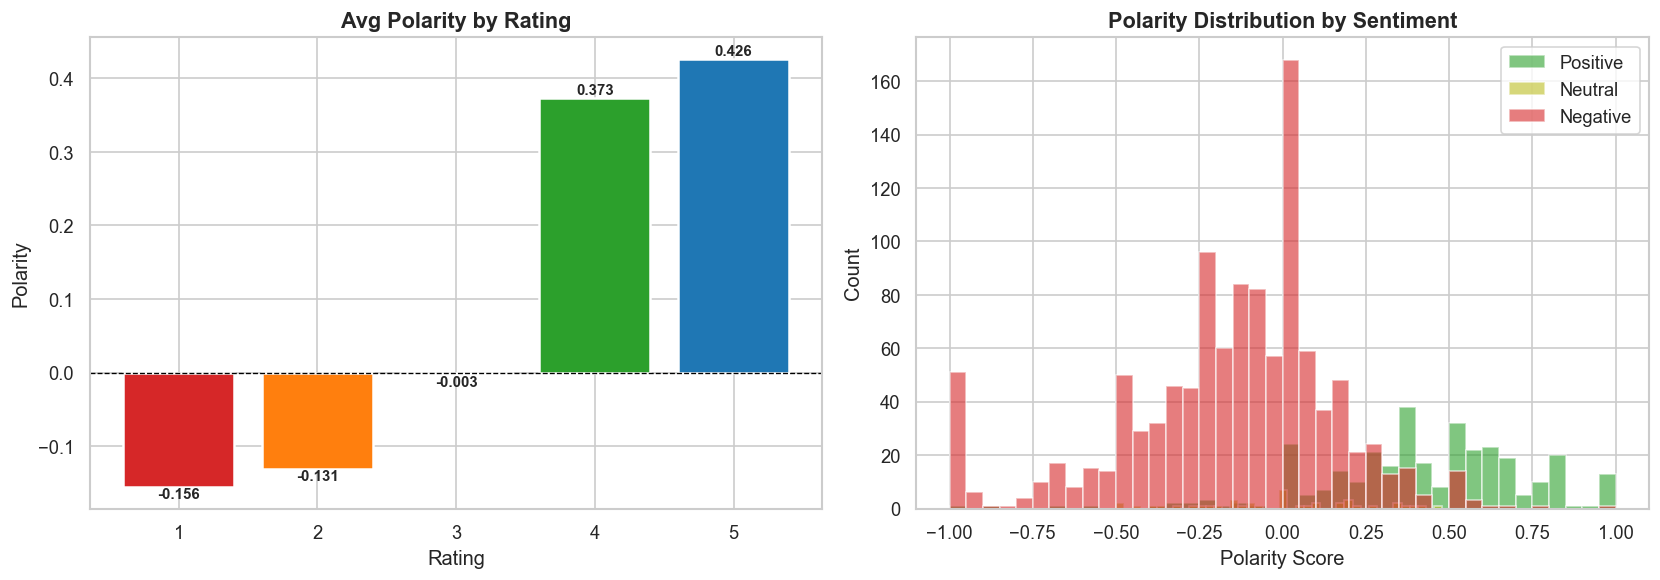

            mean  median    std
sentiment                      
Negative  -0.154  -0.100  0.319
Neutral   -0.003   0.000  0.258
Positive   0.421   0.433  0.312


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_pol = df.groupby('rating')['polarity'].mean()
axes[0].bar(avg_pol.index, avg_pol.values, color=RATING_COLORS, edgecolor='white', linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, v in zip(avg_pol.index, avg_pol.values):
    axes[0].text(i, v+0.005 if v>=0 else v-0.015, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Avg Polarity by Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Polarity')

for sent, color in SENT_COLORS.items():
    axes[1].hist(df[df['sentiment']==sent]['polarity'], bins=40, alpha=0.6,
                 color=color, label=sent, edgecolor='white')
axes[1].set_title('Polarity Distribution by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Polarity Score'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('05_polarity.png', bbox_inches='tight')
plt.show()

print(df.groupby('sentiment')['polarity'].agg(['mean','median','std']).round(3))

## 7. Review Length Analysis

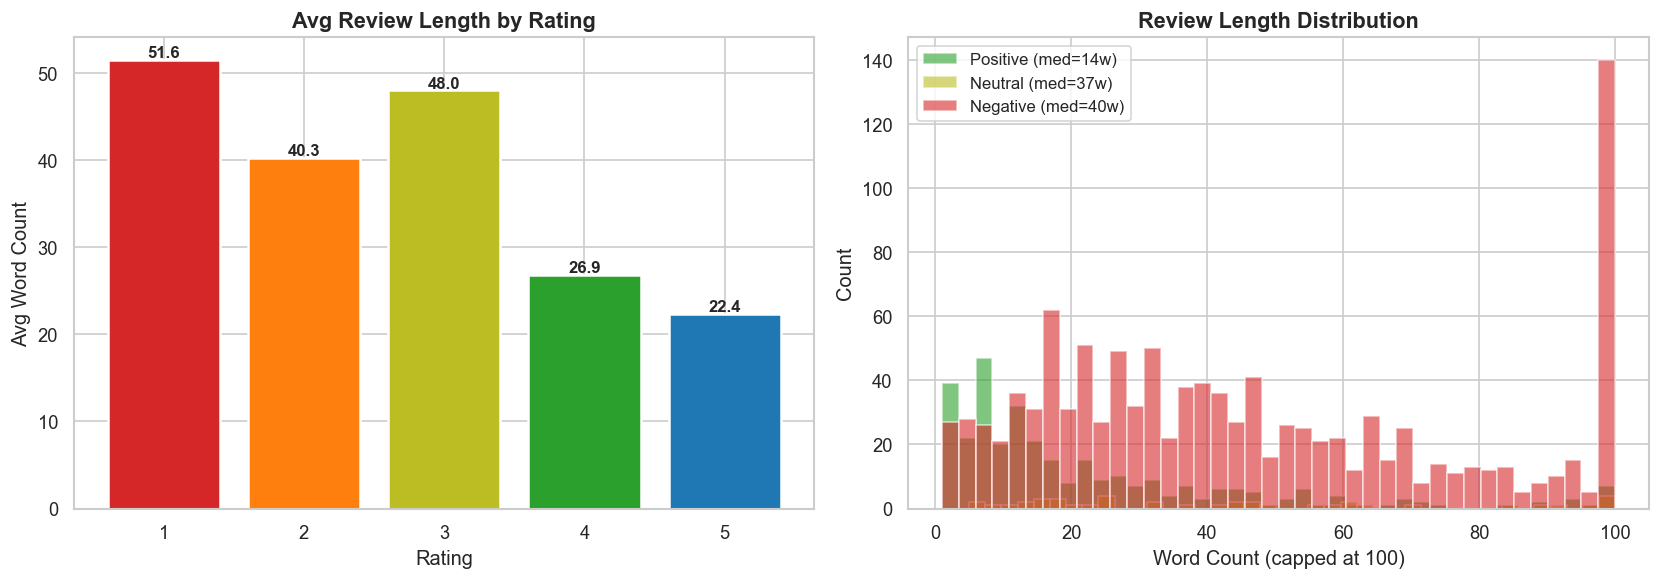

           mean  median  max
sentiment                   
Negative   51.0    40.0  376
Neutral    48.0    37.0  150
Positive   22.8    14.0  206


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_wc = df.groupby('rating')['word_count'].mean()
axes[0].bar(avg_wc.index, avg_wc.values, color=RATING_COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('Avg Review Length by Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Avg Word Count')
for i, v in zip(avg_wc.index, avg_wc.values):
    axes[0].text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

for sent, color in SENT_COLORS.items():
    subset = df[df['sentiment']==sent]['word_count']
    axes[1].hist(subset.clip(upper=100), bins=40, alpha=0.6, color=color,
                 label=f'{sent} (med={subset.median():.0f}w)', edgecolor='white')
axes[1].set_title('Review Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count (capped at 100)'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('06_review_length.png', bbox_inches='tight')
plt.show()

print(df.groupby('sentiment')['word_count'].agg(['mean','median','max']).round(1))

## 8. Word Clouds

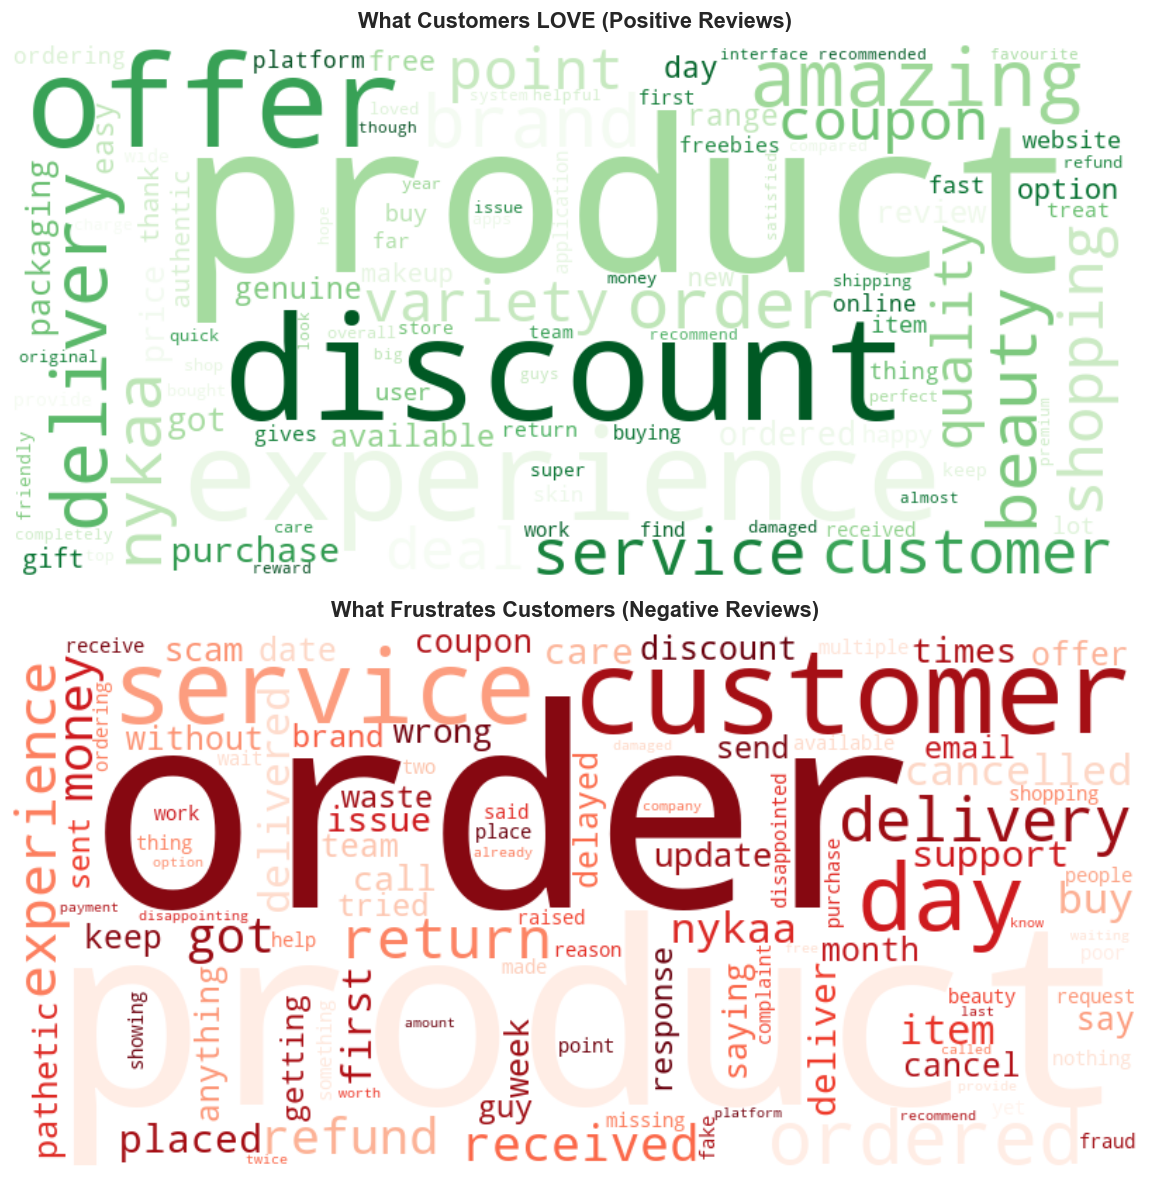

In [10]:
pos_text = ' '.join(df[df['sentiment']=='Positive']['clean_body'])
neg_text = ' '.join(df[df['sentiment']=='Negative']['clean_body'])

def make_wc(text, colormap, title, ax):
    wc = WordCloud(width=800, height=380, background_color='white',
                   colormap=colormap, max_words=100, collocations=False,
                   min_font_size=8).generate(text if text.strip() else 'no text')
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
make_wc(pos_text, 'Greens', 'What Customers LOVE (Positive Reviews)', axes[0])
make_wc(neg_text, 'Reds',   'What Frustrates Customers (Negative Reviews)', axes[1])
plt.tight_layout()
plt.savefig('07_wordclouds.png', bbox_inches='tight')
plt.show()

## 9. Top Keywords

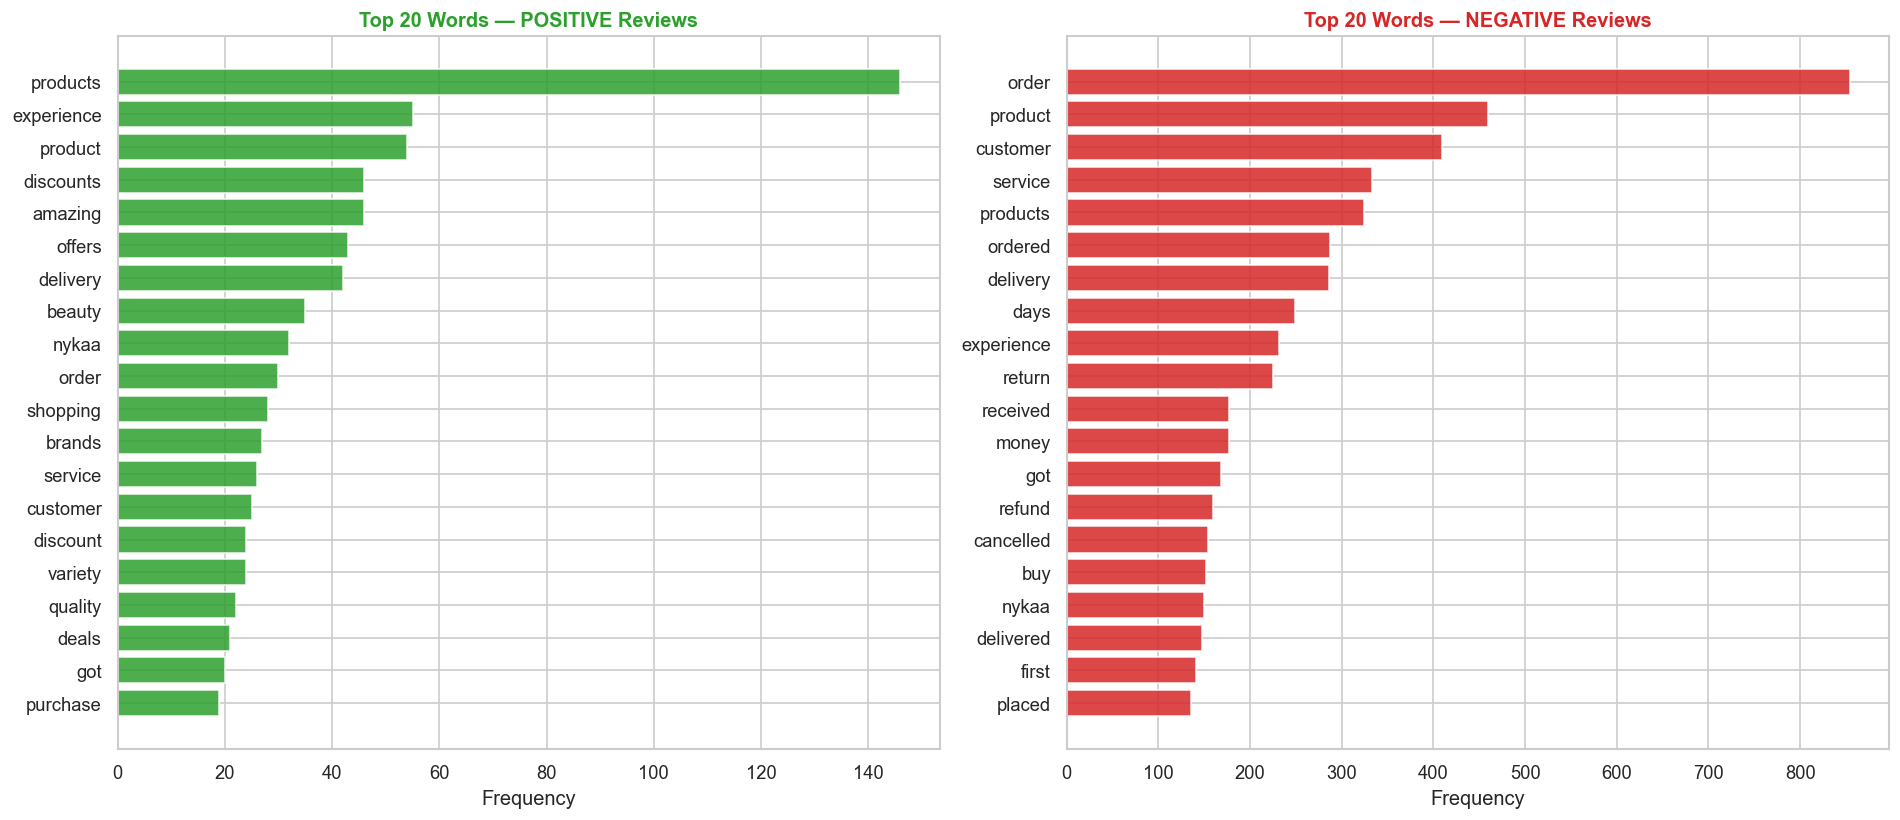

In [11]:
pos_words = Counter(pos_text.split()).most_common(20)
neg_words = Counter(neg_text.split()).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
pw, pc = zip(*pos_words)
axes[0].barh(list(pw)[::-1], list(pc)[::-1], color='#2ca02c', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 20 Words — POSITIVE Reviews', fontsize=12, fontweight='bold', color='#2ca02c')
axes[0].set_xlabel('Frequency')

nw, nc_w = zip(*neg_words)
axes[1].barh(list(nw)[::-1], list(nc_w)[::-1], color='#d62728', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 20 Words — NEGATIVE Reviews', fontsize=12, fontweight='bold', color='#d62728')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('08_top_keywords.png', bbox_inches='tight')
plt.show()

## 10. TF-IDF — Distinctive Phrases

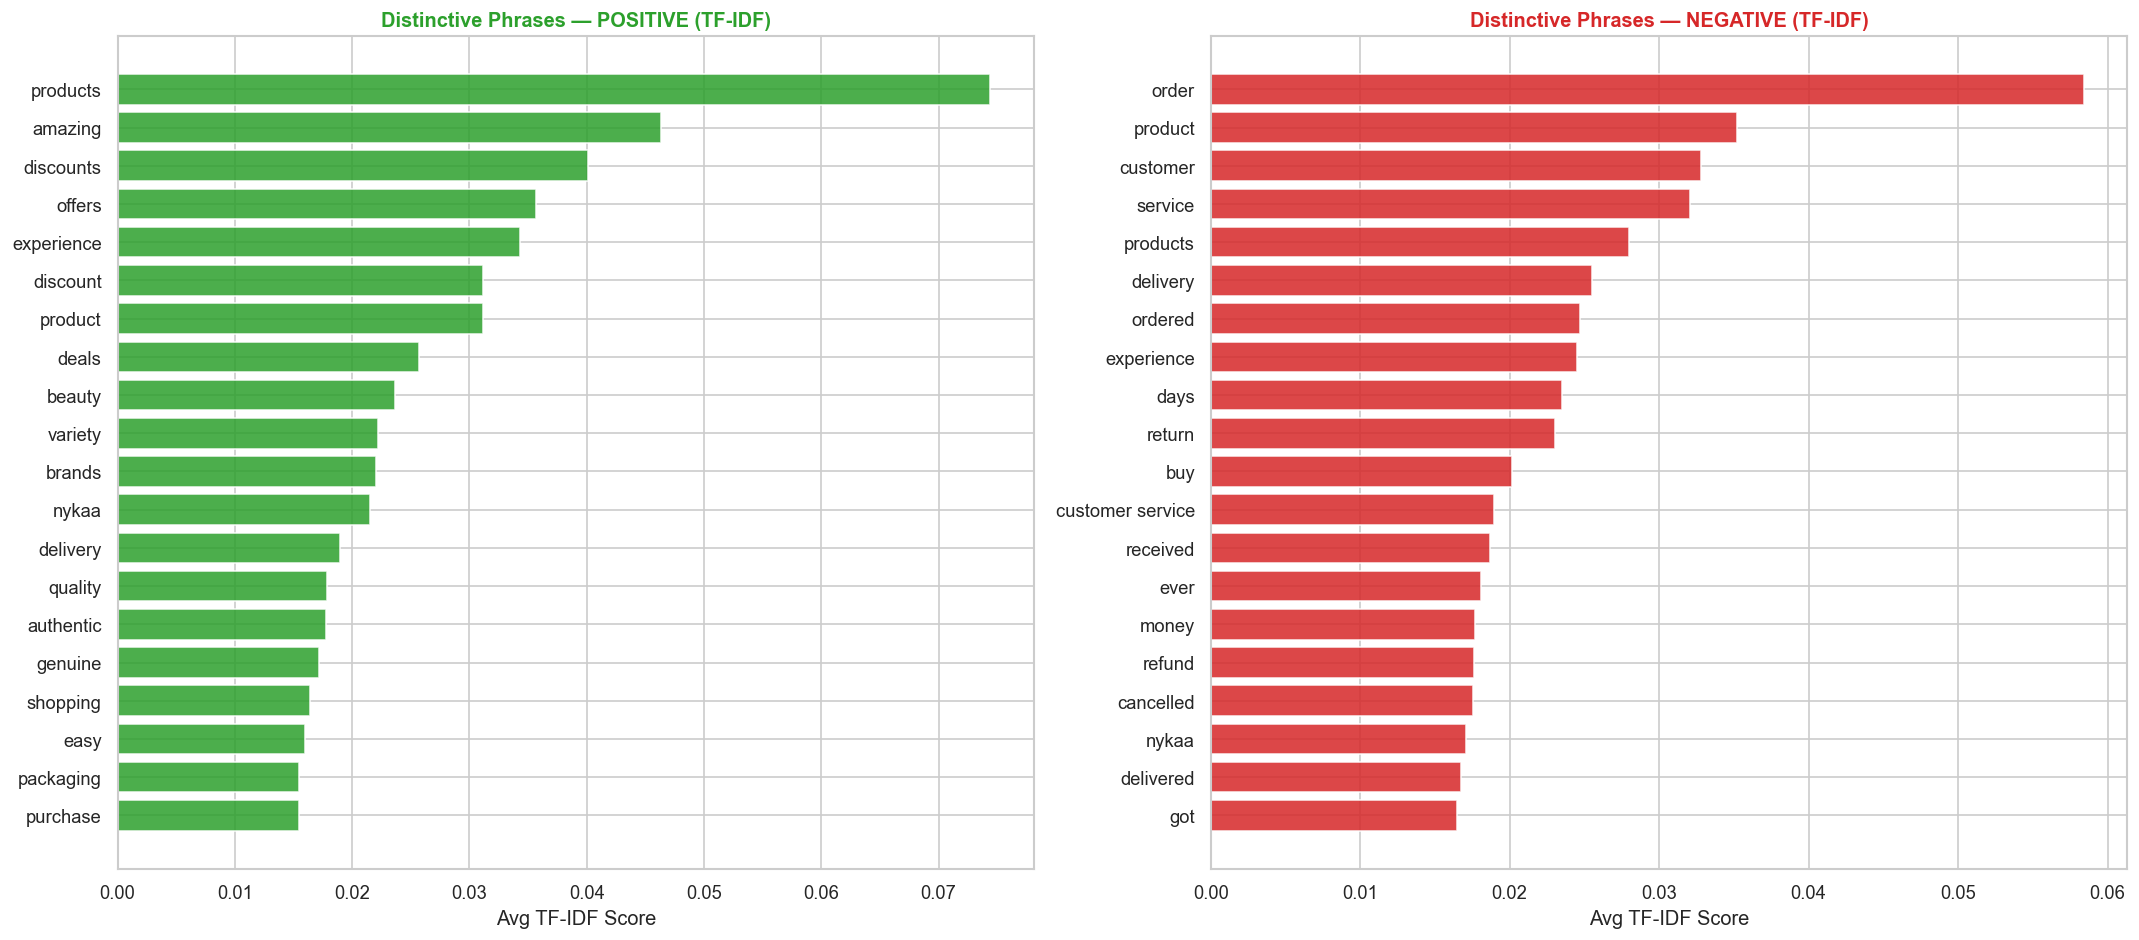

Top NEGATIVE phrases:
  order                          0.0584
  product                        0.0352
  customer                       0.0328
  service                        0.0321
  products                       0.0280
  delivery                       0.0255
  ordered                        0.0247
  experience                     0.0245
  days                           0.0235
  return                         0.0230

Top POSITIVE phrases:
  products                       0.0744
  amazing                        0.0463
  discounts                      0.0401
  offers                         0.0357
  experience                     0.0343
  discount                       0.0312
  product                        0.0311
  deals                          0.0257
  beauty                         0.0237
  variety                        0.0222


[None, None, None, None, None, None, None, None, None, None]

In [12]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3)
tfidf_matrix = tfidf.fit_transform(df['clean_body'])
feature_names = np.array(tfidf.get_feature_names_out())

def get_top_tfidf(sentiment_label, top_n=20):
    idx = df['sentiment'] == sentiment_label
    mean_scores = tfidf_matrix[idx.values].mean(axis=0).A1
    top_idx = mean_scores.argsort()[-top_n:][::-1]
    return list(zip(feature_names[top_idx], mean_scores[top_idx]))

pos_tfidf = get_top_tfidf('Positive')
neg_tfidf = get_top_tfidf('Negative')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
pw2, pv2 = zip(*pos_tfidf)
axes[0].barh(list(pw2)[::-1], list(pv2)[::-1], color='#2ca02c', edgecolor='white', alpha=0.85)
axes[0].set_title('Distinctive Phrases — POSITIVE (TF-IDF)', fontsize=12, fontweight='bold', color='#2ca02c')
axes[0].set_xlabel('Avg TF-IDF Score')

nw2, nv2 = zip(*neg_tfidf)
axes[1].barh(list(nw2)[::-1], list(nv2)[::-1], color='#d62728', edgecolor='white', alpha=0.85)
axes[1].set_title('Distinctive Phrases — NEGATIVE (TF-IDF)', fontsize=12, fontweight='bold', color='#d62728')
axes[1].set_xlabel('Avg TF-IDF Score')

plt.tight_layout()
plt.savefig('09_tfidf_keywords.png', bbox_inches='tight')
plt.show()

print('Top NEGATIVE phrases:'); [print(f'  {p:<30} {s:.4f}') for p,s in neg_tfidf[:10]]
print('\nTop POSITIVE phrases:'); [print(f'  {p:<30} {s:.4f}') for p,s in pos_tfidf[:10]]

## 11. Theme Analysis

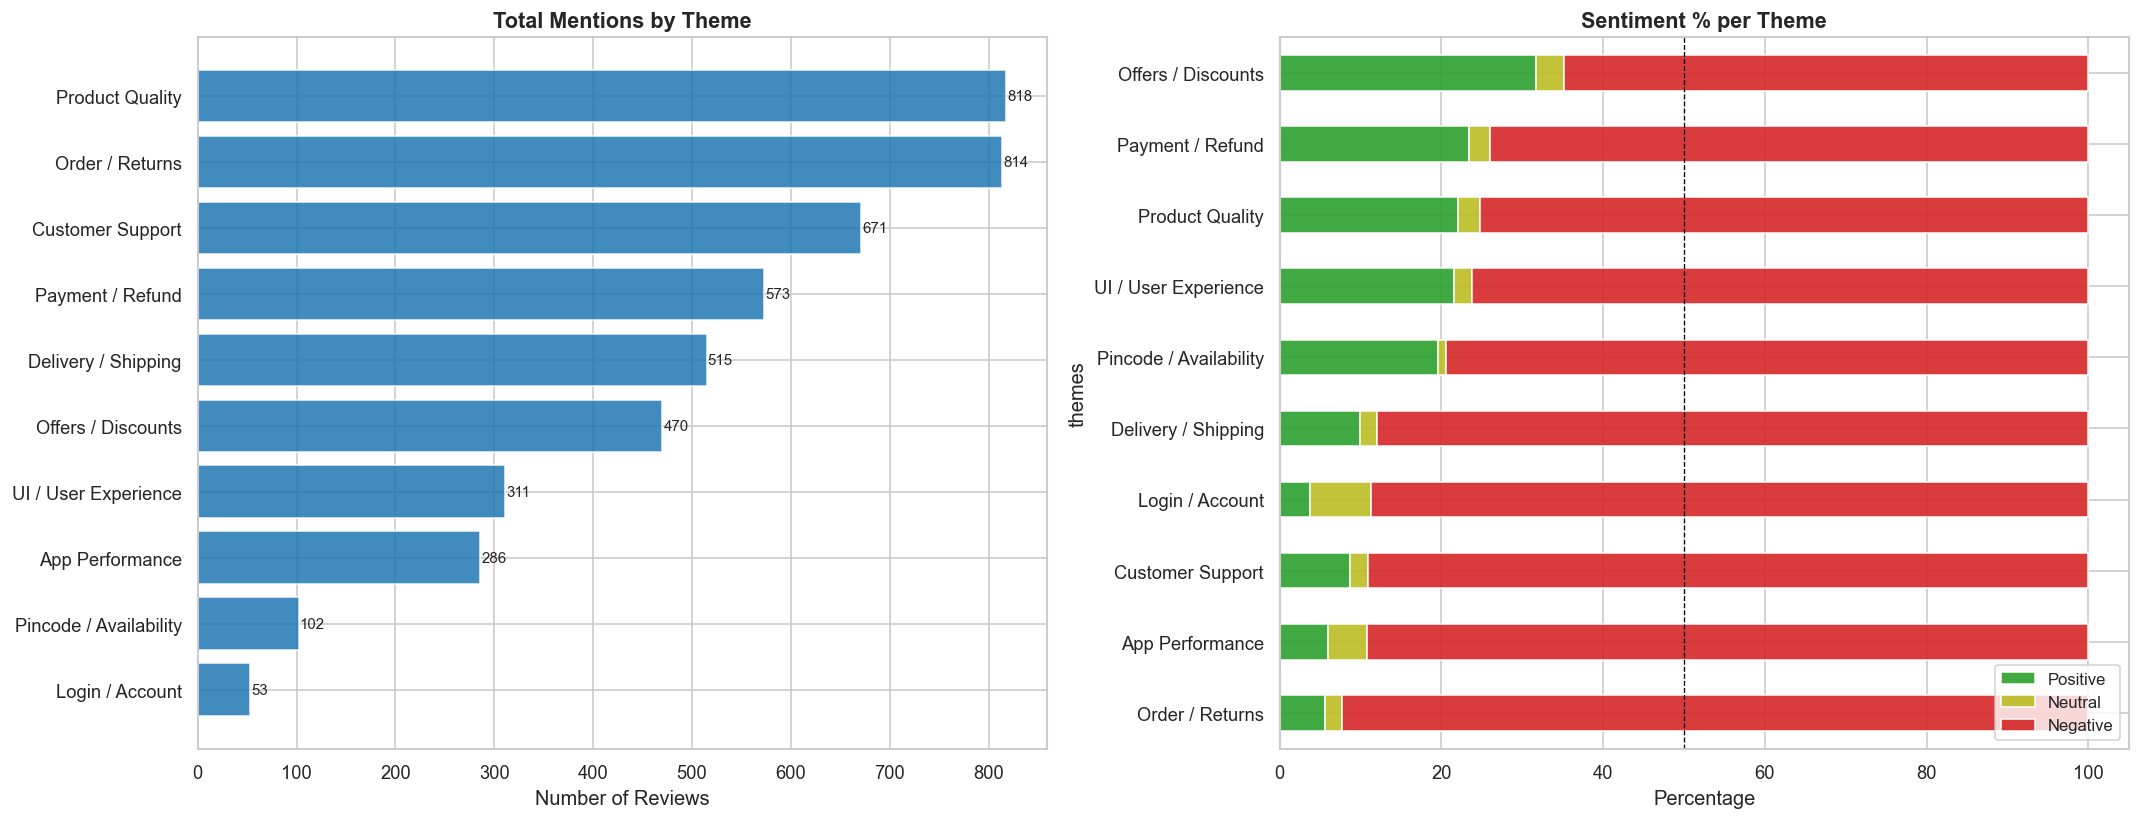

In [13]:
theme_df = df.explode('themes')
theme_sent = theme_df.groupby(['themes','sentiment']).size().unstack(fill_value=0)
for col in ['Positive','Neutral','Negative']:
    if col not in theme_sent.columns: theme_sent[col] = 0
theme_sent['total'] = theme_sent[['Positive','Neutral','Negative']].sum(axis=1)
theme_sent = theme_sent.sort_values('total', ascending=False)
theme_norm = theme_sent[['Positive','Neutral','Negative']].div(theme_sent['total'], axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_t = theme_sent[theme_sent.index != 'Other'].sort_values('total', ascending=True)
axes[0].barh(plot_t.index, plot_t['total'], color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0].set_title('Total Mentions by Theme', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
for i, (idx, row) in enumerate(plot_t.iterrows()):
    axes[0].text(row['total']+1, i, str(int(row['total'])), va='center', fontsize=9)

plot_n = theme_norm.drop('Other', errors='ignore').sort_values('Negative', ascending=False)
plot_n[['Positive','Neutral','Negative']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#2ca02c','#bcbd22','#d62728'], edgecolor='white', alpha=0.9)
axes[1].set_title('Sentiment % per Theme', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage')
axes[1].axvline(50, color='black', linewidth=0.8, linestyle='--')
axes[1].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('10_theme_analysis.png', bbox_inches='tight')
plt.show()

## 12. Pain Points & What Customers Love

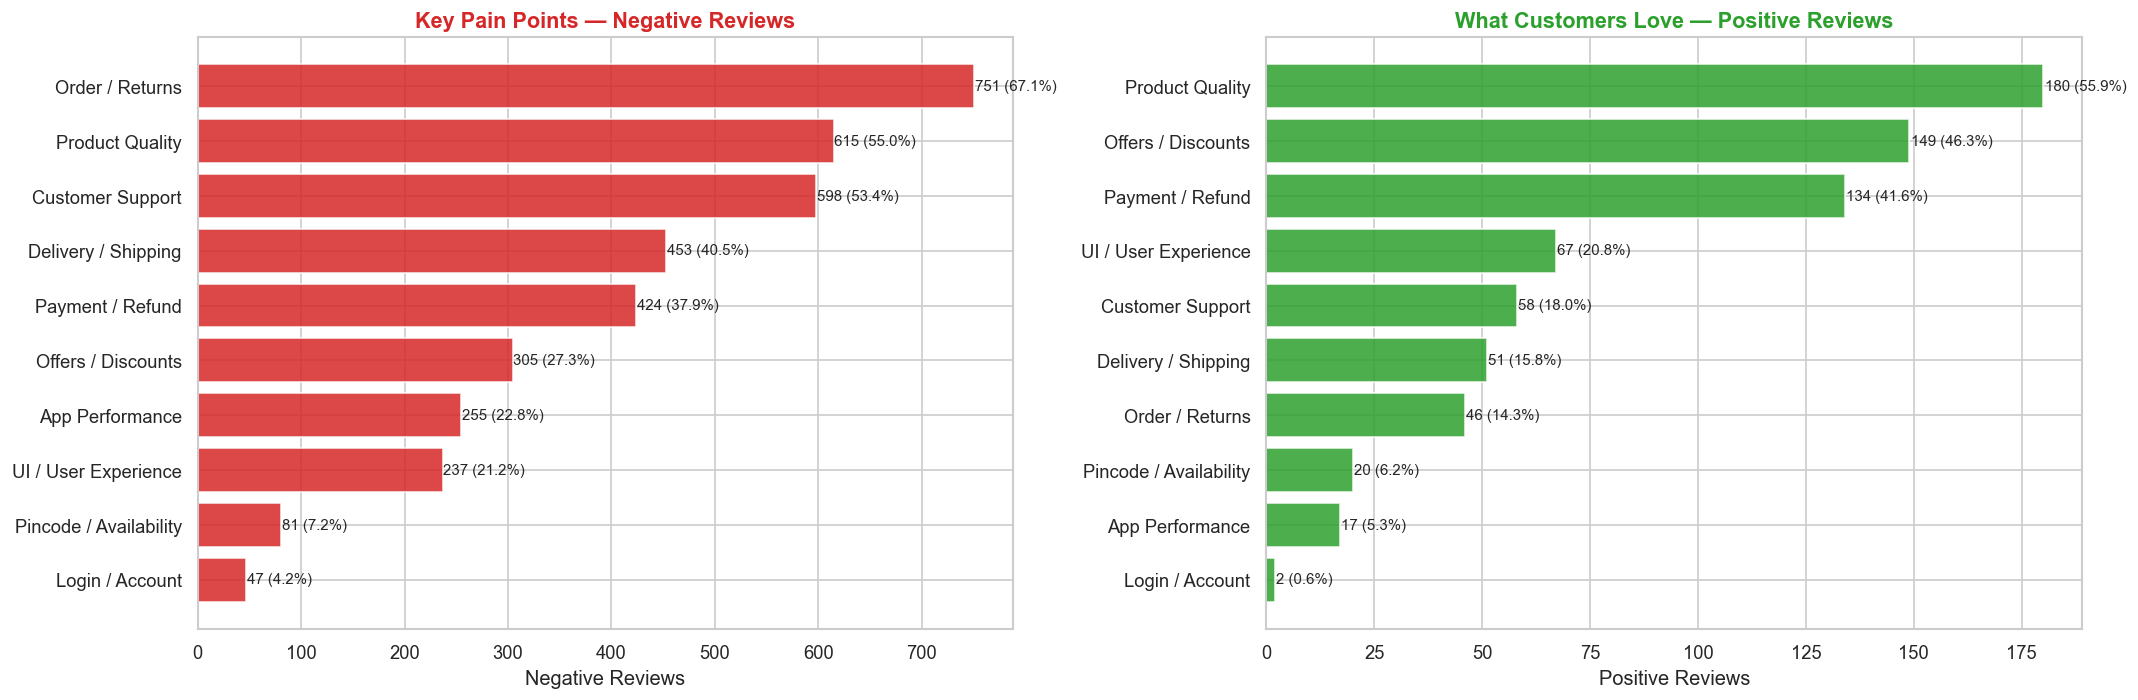

TOP PAIN POINTS:
  Order / Returns               751 (67.1%)
  Product Quality               615 (55.0%)
  Customer Support              598 (53.4%)
  Delivery / Shipping           453 (40.5%)
  Payment / Refund              424 (37.9%)
  Offers / Discounts            305 (27.3%)

WHAT CUSTOMERS LOVE:
  Product Quality               180 (55.9%)
  Offers / Discounts            149 (46.3%)
  Payment / Refund              134 (41.6%)
  UI / User Experience           67 (20.8%)
  Customer Support               58 (18.0%)
  Delivery / Shipping            51 (15.8%)


In [14]:
neg_df = df[df['sentiment']=='Negative']
pos_df = df[df['sentiment']=='Positive']
neg_tc = neg_df.explode('themes')['themes'].value_counts()
pos_tc = pos_df.explode('themes')['themes'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

nc_s = neg_tc[neg_tc.index != 'Other'].sort_values(ascending=True)
axes[0].barh(nc_s.index, nc_s.values, color='#d62728', edgecolor='white', alpha=0.85)
axes[0].set_title('Key Pain Points — Negative Reviews', fontsize=13, fontweight='bold', color='#d62728')
axes[0].set_xlabel('Negative Reviews')
for i, (t, v) in enumerate(nc_s.items()):
    axes[0].text(v+0.3, i, f'{v} ({v/len(neg_df)*100:.1f}%)', va='center', fontsize=9)

pc_s = pos_tc[pos_tc.index != 'Other'].sort_values(ascending=True)
axes[1].barh(pc_s.index, pc_s.values, color='#2ca02c', edgecolor='white', alpha=0.85)
axes[1].set_title('What Customers Love — Positive Reviews', fontsize=13, fontweight='bold', color='#2ca02c')
axes[1].set_xlabel('Positive Reviews')
for i, (t, v) in enumerate(pc_s.items()):
    axes[1].text(v+0.3, i, f'{v} ({v/len(pos_df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('11_pain_points_vs_love.png', bbox_inches='tight')
plt.show()

print('TOP PAIN POINTS:')
for t,c in neg_tc[neg_tc.index!='Other'].head(6).items():
    print(f'  {t:<28} {c:>4} ({c/len(neg_df)*100:.1f}%)')
print('\nWHAT CUSTOMERS LOVE:')
for t,c in pos_tc[pos_tc.index!='Other'].head(6).items():
    print(f'  {t:<28} {c:>4} ({c/len(pos_df)*100:.1f}%)')

## 13. Sample Reviews per Theme

In [15]:
top_neg_themes = neg_tc[neg_tc.index!='Other'].head(5).index.tolist()
top_pos_themes = pos_tc[pos_tc.index!='Other'].head(3).index.tolist()

def sample_reviews(source, theme, sentiment, n=2):
    sub = source[(source['sentiment']==sentiment) & (source['themes'].apply(lambda x: theme in x))]
    return sub.nlargest(n, 'word_count')[['rating','body']]

print('='*70)
print('TOP NEGATIVE REVIEW SAMPLES BY THEME')
print('='*70)
for theme in top_neg_themes:
    print(f'\n--- {theme.upper()} ---')
    for _, row in sample_reviews(df, theme, 'Negative').iterrows():
        print(f'  [Rating {row.rating}] {str(row.body)[:250]}')

print('\n' + '='*70)
print('TOP POSITIVE REVIEW SAMPLES BY THEME')
print('='*70)
for theme in top_pos_themes:
    print(f'\n--- {theme.upper()} ---')
    for _, row in sample_reviews(df, theme, 'Positive').iterrows():
        print(f'  [Rating {row.rating}] {str(row.body)[:250]}')

TOP NEGATIVE REVIEW SAMPLES BY THEME

--- ORDER / RETURNS ---
  [Rating 1] The very first order I placed on this app is delayed. It arrived at the local warehouse from where it should have been delivered to me within 24 hrs, but just sat there for two whole days until I complained about it on the TIRA chat support. Turns ou
  [Rating 1] So, two days ago I got an offer on a BOJ facemask and a makeup brush. It was quite unexpected because I had just added them to my cart, and suddenly the price dropped, giving me almost ₹500 off. I placed the order immediately out of desperation, thin

--- PRODUCT QUALITY ---
  [Rating 1] The very first order I placed on this app is delayed. It arrived at the local warehouse from where it should have been delivered to me within 24 hrs, but just sat there for two whole days until I complained about it on the TIRA chat support. Turns ou
  [Rating 1] So, two days ago I got an offer on a BOJ facemask and a makeup brush. It was quite unexpected because I had 

## 14. Executive Summary Dashboard

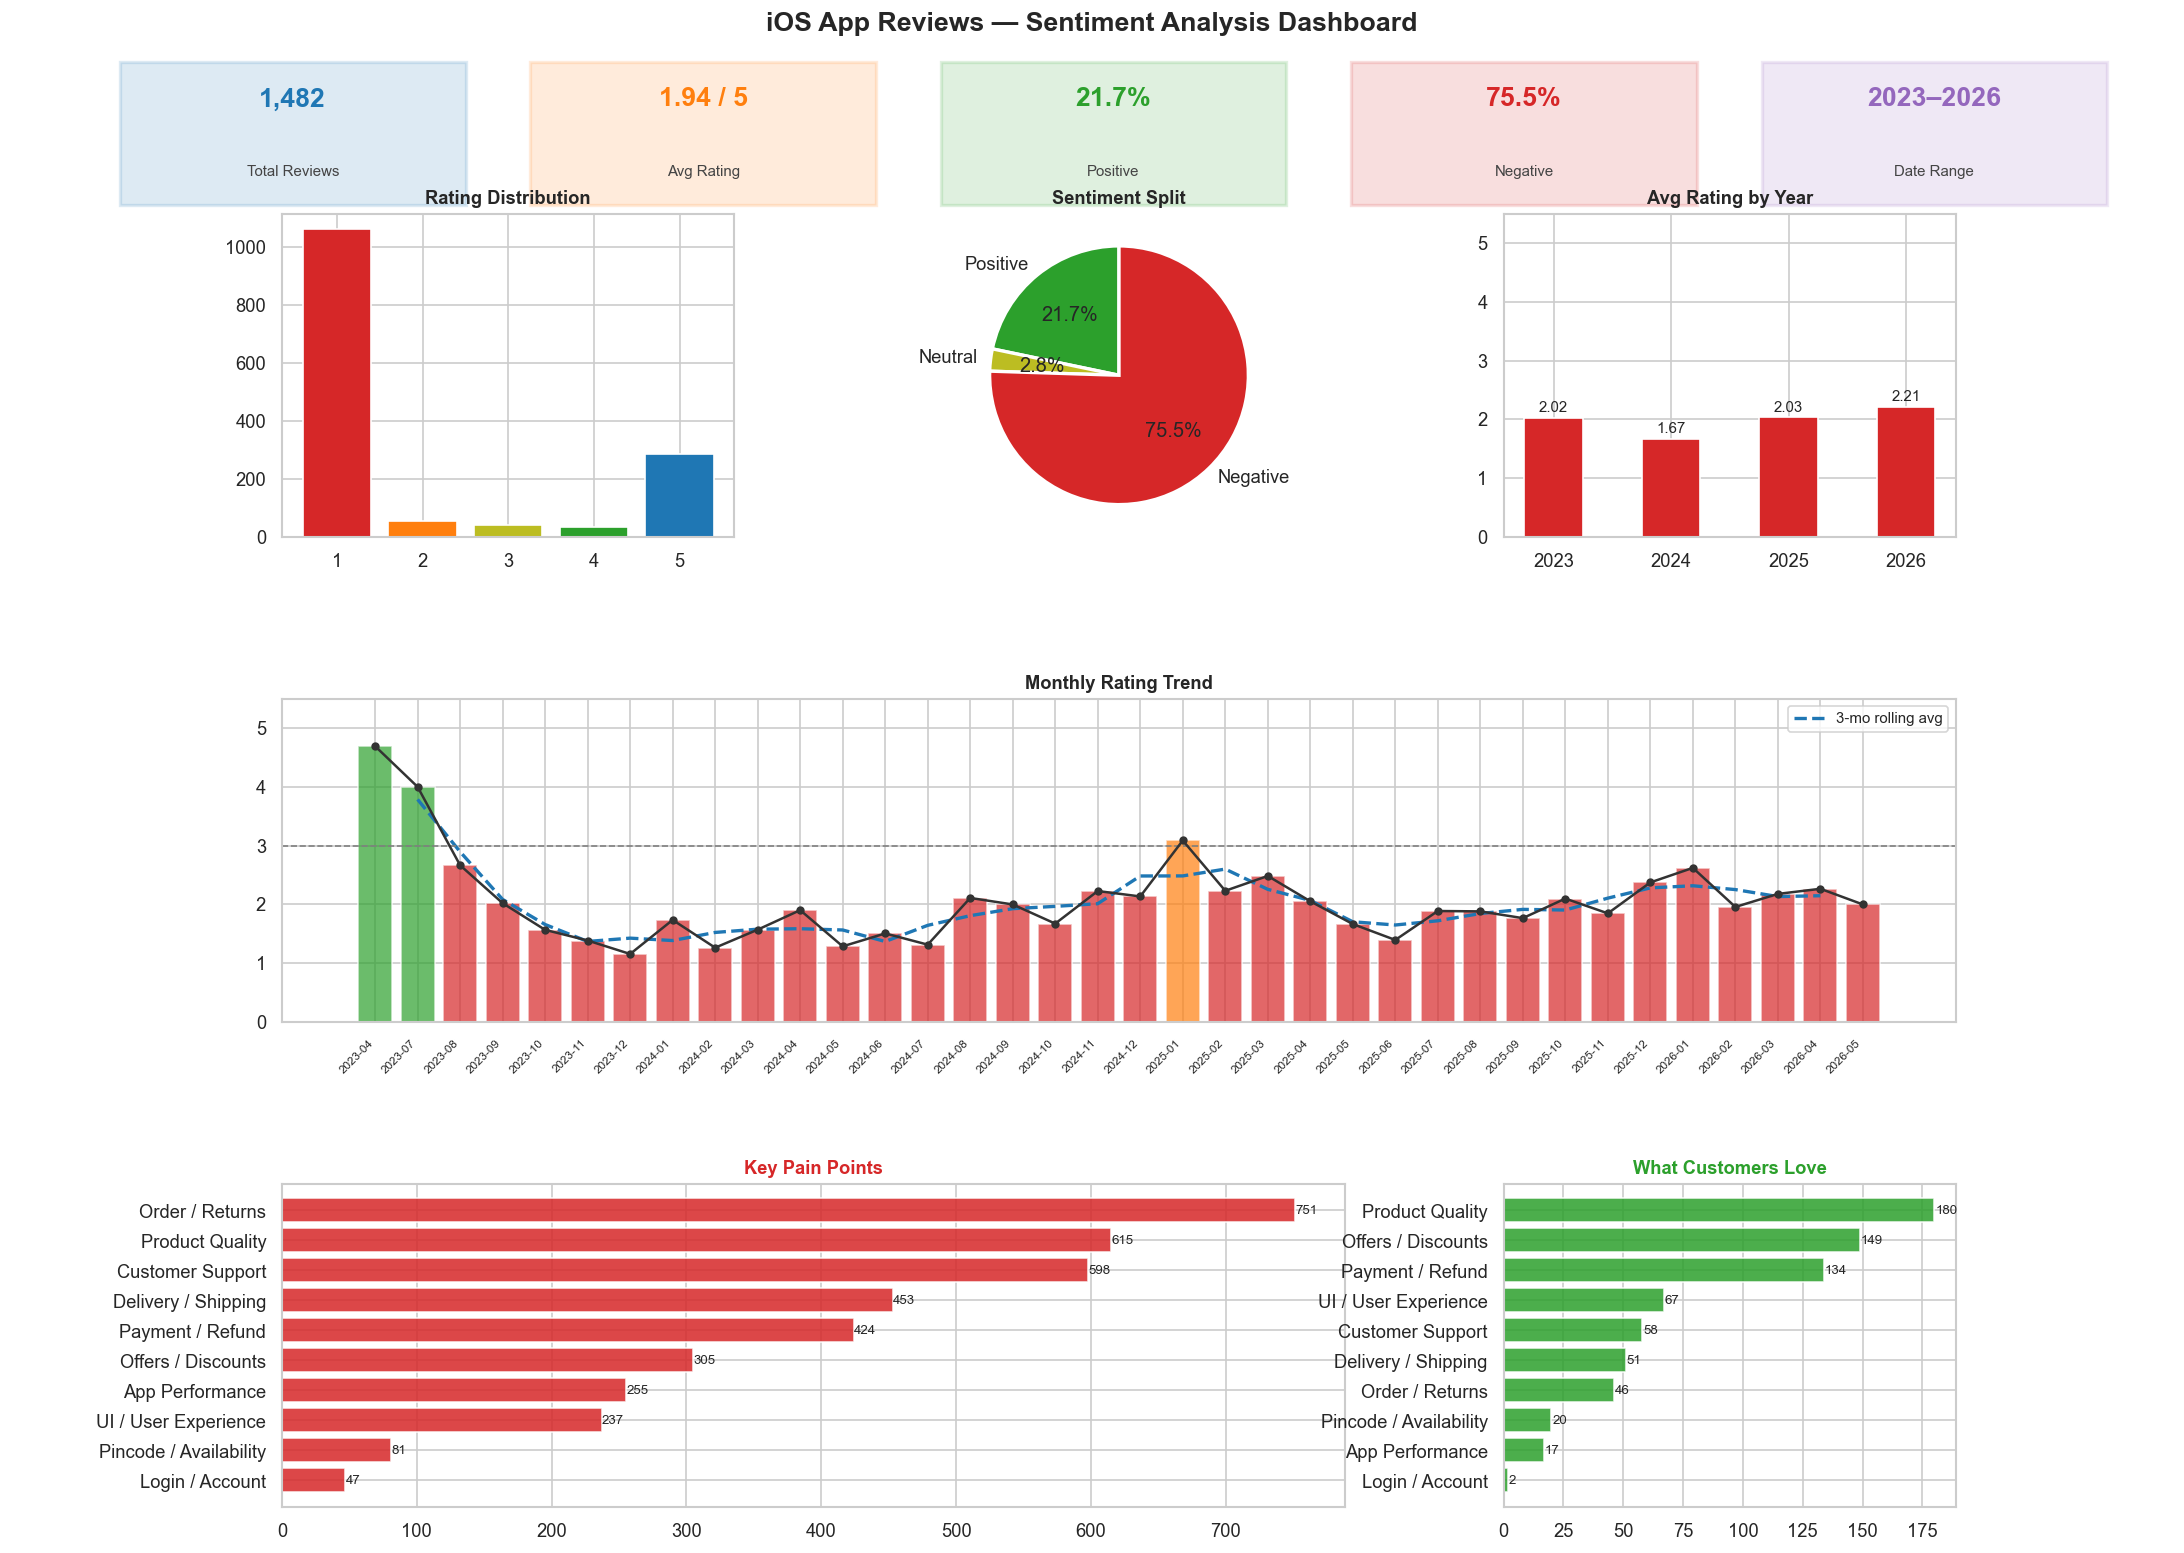

Dashboard saved.


In [16]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

kpi_ax = fig.add_axes([0, 0.88, 1, 0.1])
kpi_ax.axis('off')
kpi_items = [
    ('Total Reviews',    f'{len(df):,}',                   '#1f77b4'),
    ('Avg Rating',       f'{df["rating"].mean():.2f} / 5', '#ff7f0e'),
    (f'Positive',        f'{sp.get("Positive",0):.1f}%',   '#2ca02c'),
    (f'Negative',        f'{sp.get("Negative",0):.1f}%',   '#d62728'),
    ('Date Range',       f'{df["created_date"].dt.year.min()}–{df["created_date"].dt.year.max()}', '#9467bd'),
]
for i, (label, val, color) in enumerate(kpi_items):
    x = 0.05 + i*0.19
    kpi_ax.add_patch(plt.Rectangle((x, 0.05), 0.16, 0.85, transform=kpi_ax.transAxes,
                                    color=color, alpha=0.15, linewidth=2, edgecolor=color))
    kpi_ax.text(x+0.08, 0.68, val, ha='center', va='center', fontsize=16,
                fontweight='bold', color=color, transform=kpi_ax.transAxes)
    kpi_ax.text(x+0.08, 0.25, label, ha='center', va='center', fontsize=9,
                color='#444', transform=kpi_ax.transAxes)

# Rating dist
ax1 = fig.add_subplot(gs[0,0])
ax1.bar(rating_counts.index, rating_counts.values, color=RATING_COLORS, edgecolor='white')
ax1.set_title('Rating Distribution', fontweight='bold', fontsize=11)
ax1.set_xticks([1,2,3,4,5])

# Sentiment pie
ax2 = fig.add_subplot(gs[0,1])
ax2.pie([sc.get(s,0) for s in sent_order], labels=sent_order,
        colors=[SENT_COLORS[s] for s in sent_order],
        autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('Sentiment Split', fontweight='bold', fontsize=11)

# Yearly avg rating
ax3 = fig.add_subplot(gs[0,2])
bc_y = ['#2ca02c' if r>=4 else '#ff7f0e' if r>=3 else '#d62728' for r in yearly['avg_rating']]
ax3.bar(yearly['year'].astype(str), yearly['avg_rating'], color=bc_y, edgecolor='white', width=0.5)
ax3.set_title('Avg Rating by Year', fontweight='bold', fontsize=11)
ax3.set_ylim(0,5.5)
for i,(_, row) in enumerate(yearly.iterrows()):
    ax3.text(i, row['avg_rating']+0.1, f"{row['avg_rating']:.2f}", ha='center', fontsize=9)

# Monthly trend
ax4 = fig.add_subplot(gs[1,:])
bc_m = ['#2ca02c' if r>=4 else '#ff7f0e' if r>=3 else '#d62728' for r in monthly['avg_rating']]
ax4.bar(range(len(monthly)), monthly['avg_rating'], color=bc_m, edgecolor='white', alpha=0.7)
ax4.plot(range(len(monthly)), monthly['avg_rating'], 'o-', color='#333', linewidth=1.5, markersize=4, zorder=5)
roll = monthly['avg_rating'].rolling(3, center=True).mean()
ax4.plot(range(len(monthly)), roll, '--', color='#1f77b4', linewidth=2, label='3-mo rolling avg')
ax4.axhline(3, color='gray', linestyle='--', linewidth=1)
ax4.set_xticks(range(len(monthly)))
ax4.set_xticklabels(monthly['year_month'].tolist(), rotation=45, ha='right', fontsize=7)
ax4.set_title('Monthly Rating Trend', fontweight='bold', fontsize=11)
ax4.legend(fontsize=9); ax4.set_ylim(0,5.5)

# Pain points
ax5 = fig.add_subplot(gs[2,0:2])
nc_dash = neg_tc[neg_tc.index!='Other'].sort_values(ascending=True)
ax5.barh(nc_dash.index, nc_dash.values, color='#d62728', edgecolor='white', alpha=0.85)
ax5.set_title('Key Pain Points', fontweight='bold', fontsize=11, color='#d62728')
for i, v in enumerate(nc_dash.values):
    ax5.text(v+0.3, i, str(v), va='center', fontsize=8)

# What customers love
ax6 = fig.add_subplot(gs[2,2])
pc_dash = pos_tc[pos_tc.index!='Other'].sort_values(ascending=True)
ax6.barh(pc_dash.index, pc_dash.values, color='#2ca02c', edgecolor='white', alpha=0.85)
ax6.set_title('What Customers Love', fontweight='bold', fontsize=11, color='#2ca02c')
for i, v in enumerate(pc_dash.values):
    ax6.text(v+0.3, i, str(v), va='center', fontsize=8)

fig.suptitle('iOS App Reviews — Sentiment Analysis Dashboard', fontsize=16, fontweight='bold', y=1.0)
plt.savefig('00_executive_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print('Dashboard saved.')

## 15. Key Insights

In [17]:
best_month  = monthly.nlargest(1,'avg_rating').iloc[0]
worst_month = monthly.nsmallest(1,'avg_rating').iloc[0]
recent6 = monthly.tail(6)
trend = 'IMPROVING' if recent6.iloc[-1]['avg_rating'] > recent6.iloc[0]['avg_rating'] else 'DECLINING'

print('='*60)
print('        KEY INSIGHTS — iOS REVIEWS')
print('='*60)
print(f'Total Reviews  : {len(df):,}')
print(f'Date Range     : {df["created_date"].min().date()} to {df["created_date"].max().date()}')
print(f'Avg Rating     : {df["rating"].mean():.2f} / 5.00')
print(f'\nSentiment:')
for s in ['Positive','Neutral','Negative']:
    print(f'  {s:<10}: {sc.get(s,0):>5,} ({sp.get(s,0):.1f}%)')
print(f'\nBest Month     : {best_month["year_month"]} (avg {best_month["avg_rating"]:.2f})')
print(f'Worst Month    : {worst_month["year_month"]} (avg {worst_month["avg_rating"]:.2f})')
print(f'Recent Trend   : {trend} (last 6 months)')
print(f'\nTop Pain Points:')
for t,c in neg_tc[neg_tc.index!='Other'].head(5).items():
    print(f'  {t:<28} {c:>4} ({c/len(neg_df)*100:.1f}%)')
print(f'\nWhat Customers Love:')
for t,c in pos_tc[pos_tc.index!='Other'].head(5).items():
    print(f'  {t:<28} {c:>4} ({c/len(pos_df)*100:.1f}%)')
print('='*60)

        KEY INSIGHTS — iOS REVIEWS
Total Reviews  : 1,482
Date Range     : 2023-04-05 to 2026-05-18
Avg Rating     : 1.94 / 5.00

Sentiment:
  Positive  :   322 (21.7%)
  Neutral   :    41 (2.8%)
  Negative  : 1,119 (75.5%)

Best Month     : 2023-04 (avg 4.69)
Worst Month    : 2023-12 (avg 1.16)
Recent Trend   : DECLINING (last 6 months)

Top Pain Points:
  Order / Returns               751 (67.1%)
  Product Quality               615 (55.0%)
  Customer Support              598 (53.4%)
  Delivery / Shipping           453 (40.5%)
  Payment / Refund              424 (37.9%)

What Customers Love:
  Product Quality               180 (55.9%)
  Offers / Discounts            149 (46.3%)
  Payment / Refund              134 (41.6%)
  UI / User Experience           67 (20.8%)
  Customer Support               58 (18.0%)
